# 择时最优版

1) 连接数据源（ClickHouse）并取指数开收盘/全市场成交额
2) 读取 parquet 特征（22 个 vp_* + 35 个 market_*）
3) 从市场/情绪因子构造计算 composite_score
4) 使用连续 liquidity-based step 的仓位控制
5) 输出 NAV、回撤、仓位变化


# 数据说明
- features_A: 情绪/波动/交易行为类因子
- features_B: 市场状态类因子
- 以上在parquet文件中
- index_ret: 指数收益（用于回测）
- money_1d: 市场成交额（用于仓位步长）



In [1]:
# ===== 0) Imports =====
import os
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
# ===== 1) Data source: ClickHouse (指数 & 全市场成交额) =====
from weike_quant_db import Clickhouse
client = Clickhouse(database="default", host="10.0.10.12", port=8123, username="read_only_user", password="password", readonly=True)
import numpy as np
import pandas as pd
from datetime import datetime
import talib as ta

# -------- 配置：指数代码 & 回测区间 --------
INDEX_CODE = "000852.XSHG"  # 中证1000
START_DATE = datetime(2023, 1, 1)
END_DATE   = datetime(2025, 6, 30)

# -------- 取指数开/收盘价 & 计算 log 收益 --------
close_df = client.get("index_close_1d", START_DATE, END_DATE)
open_df  = client.get("index_open_1d",  START_DATE, END_DATE)

if INDEX_CODE not in close_df.columns or INDEX_CODE not in open_df.columns:
    # 兜底：用第一列
    code_use = close_df.columns[0]
    print(f"[WARN] {INDEX_CODE} 不在列中，自动改用第一列: {code_use}")
else:
    code_use = INDEX_CODE

index_close = close_df[code_use].astype(float).sort_index()
index_open  = open_df[code_use].astype(float).sort_index()

index_logret      = np.log(index_close / index_close.shift(1))
index_logret_open = np.log(index_open  / index_open.shift(1))
index_logret.name      = "index_logret_close"
index_logret_open.name = "index_logret_open"

# -------- 全市场成交额（money_1d 聚合） --------
def get_market_money_1d(
    client,
    start_dt: datetime,
    end_dt: datetime,
    agg: str = "sum",          # sum=全市场成交额, median/mean=更稳健
    fill_method: str = "ffill" # 缺失填充
) -> pd.Series:
    money_df = client.get("money_1d", start_dt, end_dt).sort_index()  # date x stock

    if agg == "sum":
        m = money_df.sum(axis=1, skipna=True)
    elif agg == "median":
        m = money_df.median(axis=1, skipna=True)
    elif agg == "mean":
        m = money_df.mean(axis=1, skipna=True)
    else:
        raise ValueError("agg must be one of ['sum','median','mean']")

    m = m.replace([np.inf, -np.inf], np.nan).astype(float)

    if fill_method == "ffill":
        m = m.ffill().bfill()
    elif fill_method == "bfill":
        m = m.bfill().ffill()
    elif fill_method == "none":
        pass
    else:
        raise ValueError("fill_method must be one of ['ffill','bfill','none']")
    m.name = f"market_money_1d_{agg}"
    return m

money_1d = get_market_money_1d(client, START_DATE, END_DATE, agg="sum")

# -------- 对齐索引（以指数为主） --------
idx = index_logret_open.index.union(index_logret.index).union(money_1d.index)
index_logret      = index_logret.reindex(idx)
index_logret_open = index_logret_open.reindex(idx)
money_1d          = money_1d.reindex(idx).ffill().bfill()

print("[OK] index_logret/index_logret_open/money_1d ready:", idx.min(), "->", idx.max(), "len", len(idx))


✅ 从包数据文件加载成功
✅ 因子功能已启用
✅ ClickHouse连接成功: read_only_user@10.0.10.12:8123/default
[OK] index_logret/index_logret_open/money_1d ready: 2023-01-03 00:00:00 -> 2025-06-30 00:00:00 len 601


In [ ]:
# ===== 2) Load features from parquet (22 vp_* + 35 market_*) =====
import numpy as np
import pandas as pd

PATH_22 = "/Users/yulia/Desktop/clickhouse/timing_feature/features_ABC_zz1000_20230101_20250630.parquet"
PATH_35 = "/Users/yulia/Desktop/clickhouse/market_indicators_20200101_20241231_20251109_132634.parquet"

df_22 = pd.read_parquet(PATH_22).sort_index()
if not isinstance(df_22.index, pd.DatetimeIndex):
    cand = [c for c in df_22.columns if "date" in c.lower() or "trade" in c.lower()]
    if not cand:
        raise ValueError("[22特征] parquet 既不是 DatetimeIndex，也找不到 date/trade 列")
    df_22[cand[0]] = pd.to_datetime(df_22[cand[0]])
    df_22 = df_22.set_index(cand[0]).sort_index()
feature_df_22 = df_22.select_dtypes(include=[np.number])

df_35 = pd.read_parquet(PATH_35).sort_index()
if not isinstance(df_35.index, pd.DatetimeIndex):
    cand = [c for c in df_35.columns if ("date" in c.lower() or "trade" in c.lower()) and df_35[c].notna().any()]
    if not cand:
        raise ValueError("[35特征] parquet 既不是 DatetimeIndex，也找不到可用的日期列（非全NaN）")
    df_35[cand[0]] = pd.to_datetime(df_35[cand[0]])
    df_35 = df_35.set_index(cand[0]).sort_index()
if "date" in df_35.columns and df_35["date"].isna().all():
    df_35 = df_35.drop(columns=["date"])
feature_df_35 = df_35.select_dtypes(include=[np.number]).copy()

# 合并（取交集日期）
feature_df_all = feature_df_22.join(feature_df_35, how="inner").sort_index()

# 对齐到 idx（指数/成交额的交易日序列）
feature_df_all = feature_df_all.reindex(idx).ffill()

print("[OK] feature_df_all:", feature_df_all.shape, feature_df_all.index.min(), "->", feature_df_all.index.max())


[OK] feature_df_all: (601, 56) 2023-01-03 00:00:00 -> 2025-06-30 00:00:00


In [4]:
# ===== 3) Rebuild features_A / features_B / features_C =====
cols_A = [
    "vp_turnover_weighted",
    "vp_money_ma10_over_ma60",
    "vp_price_ma10_over_ma60",
    "vp_momentum_20d",
]
cols_B = [
    "vp_industry_concentration_vol_20d",
    "vp_industry_turnover_consistency_20d",
    "vp_turnover_extreme_score",
]
cols_C = [
    "vp_market_free_turnover_5d",
    "vp_etf_activity_share_5d",
    "vp_big_inflow_share_5d",
    "vp_gem_active_share_5d",
]

missing = [c for c in cols_A+cols_B+cols_C if c not in feature_df_all.columns]
if missing:
    raise KeyError(f"feature_df_all 缺少这些列：{missing}")

features_A = feature_df_all[cols_A].copy()
features_B = feature_df_all[cols_B].copy()
features_C = feature_df_all[cols_C].copy()

# market_features（35个）
market_cols = [c for c in feature_df_all.columns if c.startswith('market_')]
market_features = feature_df_all[market_cols].copy()

print("[OK] A/B/C:", features_A.shape, features_B.shape, features_C.shape, "market:", market_features.shape)


[OK] A/B/C: (601, 4) (601, 3) (601, 4) market: (601, 34)


In [ ]:
# ===== 4) Compute composite_score =====
def zscore(s: pd.Series, w: int = 252, minp: int = 60) -> pd.Series:
    s = s.astype(float).copy()
    m = s.rolling(w, min_periods=minp).mean()
    sd = s.rolling(w, min_periods=minp).std()
    return (s - m) / (sd + 1e-8)

def zscore_ewm(s: pd.Series, span: int = 126, minp: int = 60) -> pd.Series:
    s = s.astype(float).copy()
    m = s.ewm(span=span, min_periods=minp, adjust=False).mean()
    v = s.ewm(span=span, min_periods=minp, adjust=False).var()
    sd = np.sqrt(v)
    return (s - m) / (sd + 1e-8)

def _safe_col(df: pd.DataFrame, name: str, idx: pd.DatetimeIndex) -> pd.Series:
    if (df is None) or (name not in df.columns):
        return pd.Series(index=idx, dtype=float)
    return df[name].reindex(idx).astype(float)

# ---------- A) 趋势 ----------
t1 = zscore(_safe_col(features_A, "vp_turnover_weighted", idx))
t2 = zscore(_safe_col(features_A, "vp_money_ma10_over_ma60", idx))
t3 = -zscore(_safe_col(features_A, "vp_price_ma10_over_ma60", idx))
t4 = -zscore(_safe_col(features_A, "vp_momentum_20d", idx))
trend_score = (0.6 * t1 + 0.3 * t2 + 0.05 * t3 + 0.05 * t4)

# ---------- B) 情绪：vp_* + market_* ----------
s1 = zscore(_safe_col(features_C, "vp_market_free_turnover_5d", idx))
s2 = zscore(_safe_col(features_C, "vp_etf_activity_share_5d", idx))
s3 = zscore(_safe_col(features_C, "vp_big_inflow_share_5d", idx))
s4 = -zscore(_safe_col(features_C, "vp_gem_active_share_5d", idx))
sent_raw = (s1 + s2 + s3 + 0.3 * s4) / (3.0 + 0.3)
sent_smooth = sent_raw.rolling(20, min_periods=10).mean()

m1 = zscore_ewm(_safe_col(market_features, "market_volume_zscore", idx), span=60)
m2 = zscore_ewm(_safe_col(market_features, "market_volume_ma_ratio", idx), span=60)
m3 = zscore_ewm(_safe_col(market_features, "market_money_ma_ratio", idx), span=60)
m4 = zscore_ewm(_safe_col(market_features, "market_money_percentile", idx), span=60)
m5 = zscore_ewm(_safe_col(market_features, "market_participation_index", idx), span=60)
market_sent = pd.concat([m1, m2, m3, m4, m5], axis=1).mean(axis=1, skipna=True)
market_sent_smooth = market_sent.rolling(20, min_periods=10).mean()

sent_total = 0.7 * sent_smooth + 0.3 * market_sent_smooth

# ---------- C1) 结构/拥挤 veto（原逻辑） ----------
congestion = zscore_ewm(_safe_col(features_B, "vp_industry_concentration_vol_20d", idx), span=100)
if congestion.notna().sum() > 30:
    hi_th = congestion.quantile(0.95)
    lo_th = congestion.quantile(0.05)
else:
    hi_th, lo_th = np.inf, -np.inf

veto = pd.Series(0.0, index=idx, dtype=float)
veto[congestion >= hi_th] = -2.0
veto[congestion <= lo_th] = +0.5

consis = zscore_ewm(_safe_col(features_B, "vp_industry_turnover_consistency_20d", idx), span=100)
veto_add = pd.Series(0.0, index=idx, dtype=float)
veto_add += consis.clip(-1, 1) * 0.2

ext = _safe_col(features_B, "vp_turnover_extreme_score", idx)
def _ext_penalty(x):
    if pd.isna(x): return 0.0
    if x >= 2: return -0.3
    if x <= -2: return 0.1
    return 0.0
veto_add += ext.apply(_ext_penalty)

veto_total_orig = (veto + veto_add).clip(-3.0, +1.0)

# ---------- C2) market_* 风险 veto（Step1: 更敏感分位数） ----------
rv1 = zscore_ewm(_safe_col(market_features, "market_vol_percentile", idx), span=30)
rv2 = zscore_ewm(_safe_col(market_features, "market_bb_width", idx), span=30)
rv3 = zscore_ewm(_safe_col(market_features, "market_atr", idx), span=30)
rv4 = zscore_ewm(_safe_col(market_features, "market_impact_cost", idx), span=30)
risk_score = pd.concat([rv1, rv2, rv3, rv4], axis=1).mean(axis=1, skipna=True)

# rolling quantile 阈值（window=250，hi=0.70, lo=0.30）
window = 250
hi_list, lo_list = [], []
vals = risk_score.values
for i in range(len(vals)):
    if i < 60:
        hi_list.append(np.nan); lo_list.append(np.nan)
    else:
        past = vals[max(0, i-window):i]
        past = past[~np.isnan(past)]
        if past.size == 0:
            hi_list.append(np.nan); lo_list.append(np.nan)
        else:
            hi_list.append(np.quantile(past, 0.70))
            lo_list.append(np.quantile(past, 0.30))
hi_series = pd.Series(hi_list, index=risk_score.index)
lo_series = pd.Series(lo_list, index=risk_score.index)

risk_veto = pd.Series(0.0, index=idx, dtype=float)
risk_veto[risk_score >= hi_series] = -0.7
risk_veto[risk_score <= lo_series] = -0.2

veto_total = (veto_total_orig + risk_veto).clip(-3.0, +1.0)

# ---------- D) 综合打分 ----------
composite_score = (0.6 * trend_score + 0.4 * sent_total) + veto_total
composite_score.name = "composite_score"

print("[OK] composite_score:", composite_score.dropna().head())


[OK] composite_score: date
2023-07-03    0.352256
2023-07-04    0.102199
2023-07-05   -0.824136
2023-07-06   -0.289756
2023-07-07   -0.405281
Name: composite_score, dtype: float64


✅ INTERSECT master idx: 2023-01-03 00:00:00 -> 2025-06-30 00:00:00 n = 601
✅ money source: money_1d (ALL-market)

[OPT3-INTERSECT moneyALL] CT steps (money-only) + B(target) + D(slow) + A(FULL on attack_B)
FullShare(bt): 0.15113871635610765
FastShare(bt): 0.3105590062111801
Turnover(bt):  33.26624551498423

=== Open-open Performance (OPT3-INTERSECT (moneyALL, rolling z + FULL)) ===
           Index  Strategy
AnnRet -0.017003  0.219340
AnnVol  0.312354  0.241940
Sharpe -0.054436  0.906591
MaxDD  -0.362251 -0.157164
EndNAV  0.967665  1.462422
Hit     0.474120  0.461698


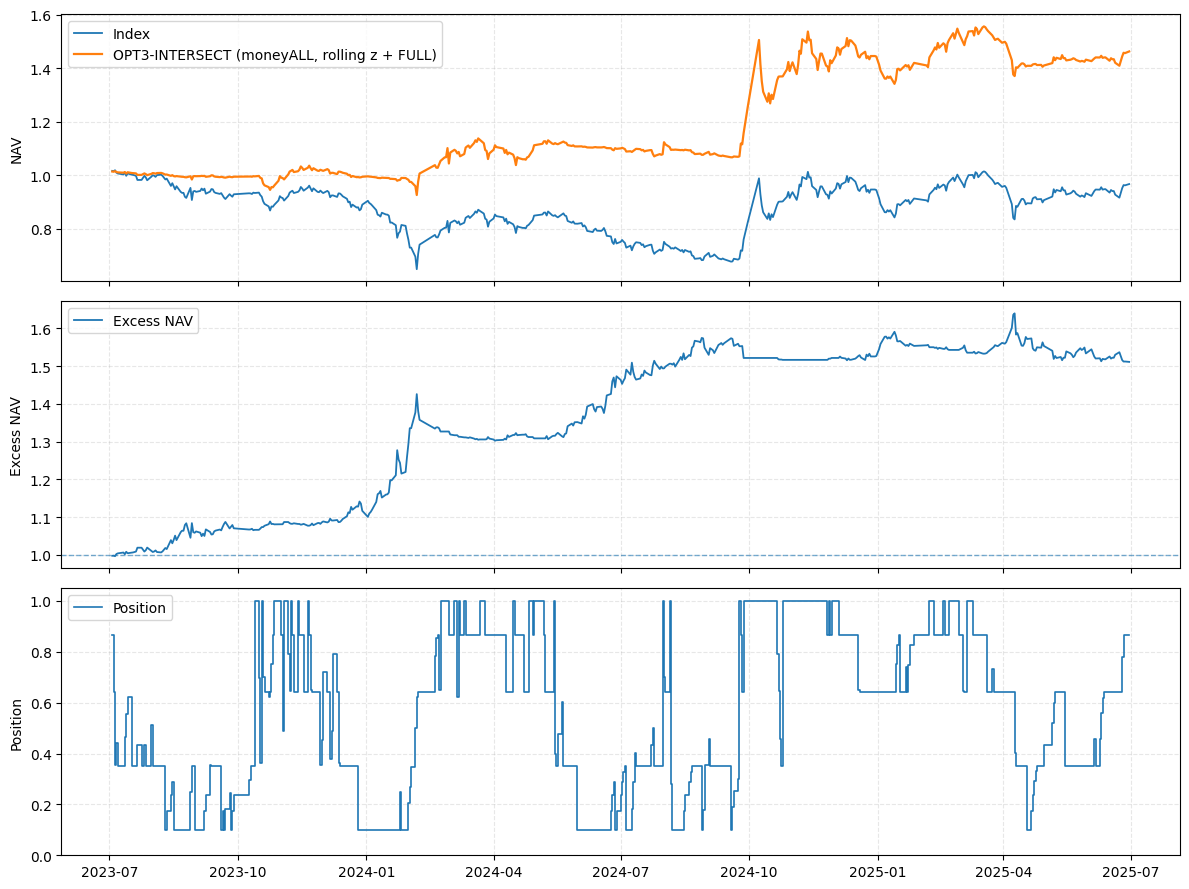

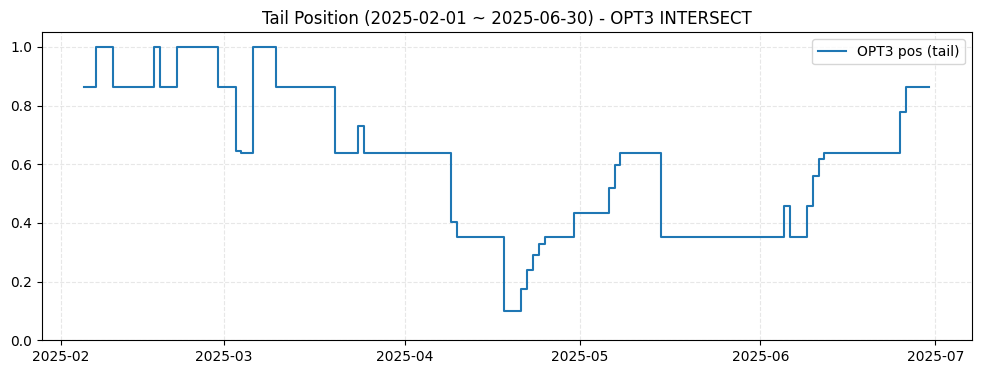

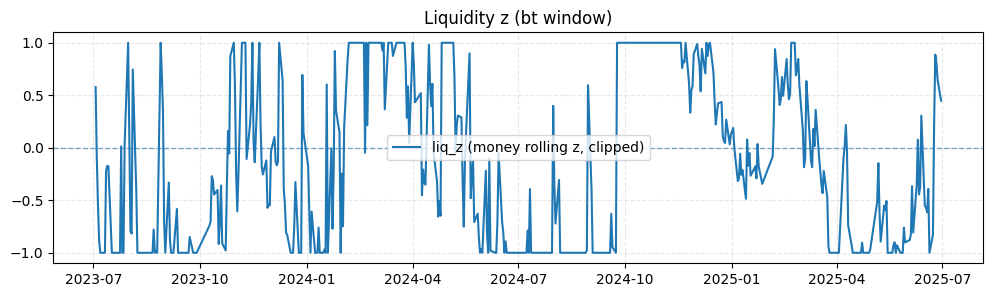

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BT_START = "2023-07-01"
BT_END   = "2025-06-30"
POS_ATTACK = 0.85

# -----------------------
# 0) Utils
# -----------------------
def as_series(x, name=None) -> pd.Series:
    if isinstance(x, pd.Series):
        s = x.copy()
    elif isinstance(x, pd.DataFrame):
        s = x.iloc[:, 0].copy()
    else:
        raise TypeError(f"Expect Series/DataFrame, got {type(x)}")
    s = s.sort_index().astype(float)
    if name is not None:
        s.name = name
    return s

def _max_drawdown(nav: pd.Series) -> float:
    nav = as_series(nav)
    cum_max = nav.cummax()
    dd = nav / cum_max - 1.0
    return float(dd.min())

def perf_stats_fallback_logret(r: pd.Series) -> pd.Series:
    r = as_series(r, "logret").fillna(0.0)
    ann = 252
    n = len(r)
    nav = np.exp(r.cumsum())
    out = {}
    out["AnnRet"] = float(np.exp(r.sum() * (ann / max(n,1))) - 1.0) if n > 1 else np.nan
    out["AnnVol"] = float(r.std() * np.sqrt(ann)) if n > 1 else np.nan
    out["Sharpe"] = float(out["AnnRet"] / (out["AnnVol"] + 1e-12)) if np.isfinite(out["AnnVol"]) else np.nan
    out["MaxDD"]  = _max_drawdown(nav) if n > 1 else np.nan
    out["EndNAV"] = float(nav.iloc[-1]) if n > 0 else np.nan
    return pd.Series(out)

def _as_param_series(x, index, name: str) -> pd.Series:
    if np.isscalar(x):
        return pd.Series(float(x), index=index, name=name)
    s = as_series(x, name=name).reindex(index)
    return s.ffill().bfill()

# -----------------------
# 1) Target: 方案B（attackable target）
# -----------------------
def target_pos_from_score_attackable(
    score: pd.Series,
    pos_floor: float = 0.10,
    pos_ceil: float = 1.00,
    full_th: float = 0.70,
    high_th: float = 0.55,
    mid_th: float  = 0.40,
    low_th: float  = 0.25
) -> pd.Series:
    score = as_series(score, "score")
    s = score.clip(-2.0, 2.0)
    strength = (s + 2.0) / 4.0  # [0,1]

    tgt = pd.Series(index=score.index, dtype=float)
    tgt[strength <= low_th] = pos_floor
    tgt[(strength > low_th) & (strength <= mid_th)] = pos_floor + 0.28 * (pos_ceil - pos_floor)
    tgt[(strength > mid_th) & (strength <= high_th)] = pos_floor + 0.60 * (pos_ceil - pos_floor)
    tgt[(strength > high_th) & (strength <= full_th)] = pos_floor + 0.85 * (pos_ceil - pos_floor)
    tgt[strength > full_th] = pos_ceil
    return tgt.rename("pos_target")

# -----------------------
# 2) Slow: D（支持动态步长 series）
# -----------------------
def follow_target_with_asym_steps_dynamic_up(
    pos_target: pd.Series,
    pos_init: float = 1.0,
    step_down_big: float = 0.50,
    step_down_small: float = 0.15,
    step_up_min: float = 0.03,
    step_up_max: float = 0.10,
    step_up_big: float = 0.22,
    up_power: float = 0.60,
    pos_floor: float = 0.10,
    pos_ceil: float = 1.00,
) -> pd.Series:
    pos_target = as_series(pos_target, "pos_target")
    idx = pos_target.index

    d_big_s   = _as_param_series(step_down_big,   idx, "step_down_big")
    d_small_s = _as_param_series(step_down_small, idx, "step_down_small")
    u_min_s   = _as_param_series(step_up_min,     idx, "step_up_min")
    u_max_s   = _as_param_series(step_up_max,     idx, "step_up_max")
    u_big_s   = _as_param_series(step_up_big,     idx, "step_up_big")

    pos_actual = pd.Series(index=idx, dtype=float)
    last = float(pos_init)

    for t in idx:
        tgt = pos_target.loc[t]
        if pd.isna(tgt):
            pos_actual.loc[t] = last
            continue

        d_big   = float(d_big_s.loc[t])
        d_small = float(d_small_s.loc[t])
        u_min   = float(u_min_s.loc[t])
        u_max   = float(u_max_s.loc[t])
        u_big   = float(u_big_s.loc[t])

        step_up_cap = float(max(u_big, u_max))

        if tgt < last:
            gap = last - tgt
            w = min(max(gap, 0.0), 1.0)
            step = d_small + w * (d_big - d_small)
            new_pos = max(last - step, tgt)

        elif tgt > last:
            gap_up = tgt - last
            w_up = min(max(gap_up, 0.0), 1.0)
            w_adj = float(w_up ** up_power)
            step_up = u_min + w_adj * (step_up_cap - u_min)
            new_pos = min(last + step_up, tgt)

        else:
            new_pos = last

        new_pos = float(np.clip(new_pos, pos_floor, pos_ceil))
        pos_actual.loc[t] = new_pos
        last = new_pos

    return pos_actual.rename("pos_slow")

# -----------------------
# 3) Fast: A（attack触发时：FULL -> 满仓）
# -----------------------
def follow_target_buy_attack_accelerator(
    pos_target: pd.Series,
    pos_init: float = 1.0,
    step_down_big: float = 0.50,
    step_down_small: float = 0.15,
    pos_attack: float = 0.85,
    pos_floor: float = 0.10,
    pos_ceil: float = 1.00,
    buy_mode: str = "FULL"
) -> pd.Series:
    pos_target = as_series(pos_target, "pos_target")
    idx = pos_target.index

    d_big_s   = _as_param_series(step_down_big,   idx, "step_down_big")
    d_small_s = _as_param_series(step_down_small, idx, "step_down_small")

    pos_actual = pd.Series(index=idx, dtype=float)
    last = float(pos_init)
    pos_attack = float(np.clip(pos_attack, pos_floor, pos_ceil))

    for t in idx:
        tgt = pos_target.loc[t]
        if pd.isna(tgt):
            pos_actual.loc[t] = last
            continue

        d_big   = float(d_big_s.loc[t])
        d_small = float(d_small_s.loc[t])

        if tgt < last:
            gap = last - tgt
            w = min(max(gap, 0.0), 1.0)
            step = d_small + w * (d_big - d_small)
            new_pos = max(last - step, tgt)

        elif tgt > last:
            if buy_mode == "FULL":
                new_pos = pos_ceil
            else:
                new_pos = last

        else:
            new_pos = last

        new_pos = float(np.clip(new_pos, pos_floor, pos_ceil))
        pos_actual.loc[t] = new_pos
        last = new_pos

    return pos_actual.rename("pos_fast")

# -----------------------
# 4) Signals: attack_B
# -----------------------
def build_attack_mask_B(
    composite_score: pd.Series,
    index_logret_open: pd.Series,
    q: float = 0.7,
    q_win: int = 252,
    risk_win: int = 20,
    risk_th: float = -0.05,
    min_periods: int = 60
) -> pd.Series:
    s = as_series(composite_score, "score")
    r = as_series(index_logret_open, "idx_logret_open").reindex(s.index).fillna(0.0)

    thresh = s.rolling(q_win, min_periods=min_periods).quantile(q)
    cond1 = s > thresh

    roll = np.exp(r.rolling(risk_win, min_periods=max(5, risk_win//2)).sum()) - 1.0
    cond2 = roll > risk_th

    out = (cond1 & cond2).fillna(False)
    return out.rename("attack_B")

# -----------------------
# 5) Mixer
# -----------------------
def mix_positions_by_mask(pos_slow, pos_fast, fast_mask, pos_floor=0.10, pos_ceil=1.00):
    pos_slow = as_series(pos_slow, "pos_slow")
    pos_fast = as_series(pos_fast, "pos_fast").reindex(pos_slow.index)
    m = pd.Series(fast_mask, index=pos_slow.index).reindex(pos_slow.index).fillna(False).astype(bool)
    out = pos_slow.copy()
    out[m] = pos_fast[m]
    return out.clip(pos_floor, pos_ceil).rename("pos_mix")

# -----------------------
# 6) Backtest (open-open) + plots
# -----------------------
def backtest_open_open(
    pos: pd.Series,
    index_logret_open: pd.Series,
    bt_start=BT_START,
    bt_end=BT_END,
    title="Strategy",
    plot=True
):
    pos = as_series(pos, "pos")
    r = as_series(index_logret_open, "idx_logret_open")

    bt_start = pd.Timestamp(bt_start)
    bt_end   = pd.Timestamp(bt_end)

    pos_bt = pos.loc[bt_start:bt_end].copy()
    r_bt   = r.reindex(pos_bt.index).fillna(0.0)

    # open-open: use yesterday's pos
    pos_used = pos_bt.shift(1).ffill()
    if len(pos_used) > 0:
        pos_used.iloc[0] = pos_bt.iloc[0]
    pos_used = pos_used.fillna(pos_bt.iloc[0])

    ret_str = pos_used * r_bt

    nav_idx = np.exp(r_bt.cumsum())
    nav_str = np.exp(ret_str.cumsum())
    nav_ex  = nav_str / nav_idx

    stats_idx = perf_stats_fallback_logret(r_bt)
    stats_str = perf_stats_fallback_logret(ret_str)

    comp = pd.DataFrame({"Index": stats_idx, "Strategy": stats_str})
    comp.loc["Hit", "Index"] = float((r_bt > 0).mean())
    comp.loc["Hit", "Strategy"] = float((ret_str > r_bt).mean())

    print(f"\n=== Open-open Performance ({title}) ===")
    print(comp)

    if plot:
        fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

        axes[0].plot(nav_idx.index, nav_idx, label="Index", linewidth=1.3)
        axes[0].plot(nav_str.index, nav_str, label=title, linewidth=1.6)
        axes[0].set_ylabel("NAV"); axes[0].legend(loc="upper left")
        axes[0].grid(True, linestyle="--", alpha=0.3)

        axes[1].plot(nav_ex.index, nav_ex, label="Excess NAV", linewidth=1.3)
        axes[1].axhline(1.0, linestyle="--", linewidth=1.0, alpha=0.6)
        axes[1].set_ylabel("Excess NAV"); axes[1].legend(loc="upper left")
        axes[1].grid(True, linestyle="--", alpha=0.3)

        axes[2].step(pos_bt.index, pos_bt, where="post", label="Position", linewidth=1.2)
        axes[2].set_ylabel("Position"); axes[2].set_ylim(0, 1.05)
        axes[2].legend(loc="upper left"); axes[2].grid(True, linestyle="--", alpha=0.3)

        plt.tight_layout()
        plt.show()

    return {
        "comp": comp,
        "pos_bt": pos_bt,
        "ret_idx": r_bt,
        "ret_str": ret_str,
        "nav_idx": nav_idx,
        "nav_str": nav_str,
        "nav_ex": nav_ex,
    }

# -----------------------
# 7) CT steps from money (rolling z)
# -----------------------
def build_steps_from_money_continuous(
    money_1d: pd.Series,
    z_win: int = 120,
    clip_z: float = 1.0,
    base = dict(step_up_min=0.030, step_up_max=0.100, step_up_big=0.22, step_down_big=0.50, step_down_small=0.15),
    amp  = dict(step_up_min=0.020, step_up_max=0.050, step_up_big=0.06, step_down_big=-0.10, step_down_small=-0.05),
):
    m = as_series(money_1d, "money_1d")
    mu = m.rolling(z_win, min_periods=max(30, z_win//3)).mean()
    sd = m.rolling(z_win, min_periods=max(30, z_win//3)).std().replace(0.0, np.nan)
    z = ((m - mu) / sd).clip(-clip_z, clip_z).fillna(0.0)  # [-1,1]
    cols = ["step_up_min","step_up_max","step_up_big","step_down_big","step_down_small"]
    out = pd.DataFrame(index=m.index, columns=cols, dtype=float)
    for c in cols:
        out[c] = base[c] + amp[c] * z
    out["liq_z"] = z
    return out

# ======================================================
# 8) RUN (INTERSECT-style)
# ======================================================
# required inputs
score_raw  = as_series(composite_score, "score")
r_open_raw = as_series(index_logret_open, "r_open")

if "money_1d" not in globals():
    raise NameError("你要跑 moneyALL 版本，请先在 notebook 里准备好 money_1d（全市场成交额）")

money_raw  = as_series(money_1d, "money_1d")

# master index = intersection
idx = score_raw.index.intersection(r_open_raw.index)
score  = score_raw.reindex(idx).ffill()
r_open = r_open_raw.reindex(idx).fillna(0.0)
money  = money_raw.reindex(idx).ffill().bfill()

print("✅ INTERSECT master idx:", idx.min(), "->", idx.max(), "n =", len(idx))
print("✅ money source:", "money_1d (ALL-market)")

# signals
attack_B = build_attack_mask_B(score, r_open, q=0.7, q_win=252, risk_win=20, risk_th=-0.05, min_periods=60)

# target
pos_target = target_pos_from_score_attackable(score).clip(0.10, 1.00)

# CT steps
steps_ct = build_steps_from_money_continuous(money, z_win=120, clip_z=1.0)

# slow D
pos_slow = follow_target_with_asym_steps_dynamic_up(
    pos_target, pos_init=1.0,
    step_down_big=steps_ct["step_down_big"],
    step_down_small=steps_ct["step_down_small"],
    step_up_min=steps_ct["step_up_min"],
    step_up_max=steps_ct["step_up_max"],
    step_up_big=steps_ct["step_up_big"],
    up_power=0.60,
    pos_floor=0.10, pos_ceil=1.00
).clip(0.10, 1.00)

# fast A (FULL on attack_B)
pos_fast = follow_target_buy_attack_accelerator(
    pos_target, pos_init=1.0,
    step_down_big=steps_ct["step_down_big"],
    step_down_small=steps_ct["step_down_small"],
    pos_attack=POS_ATTACK,
    pos_floor=0.10, pos_ceil=1.00,
    buy_mode="FULL"
).clip(0.10, 1.00)

# mix
pos_mix = mix_positions_by_mask(pos_slow, pos_fast, attack_B, pos_floor=0.10, pos_ceil=1.00)

# quick diagnostics
bt_s = pd.Timestamp(BT_START); bt_e = pd.Timestamp(BT_END)
pos_bt = pos_mix.loc[bt_s:bt_e]
print("\n" + "="*80)
print("[OPT3-INTERSECT moneyALL] CT steps (money-only) + B(target) + D(slow) + A(FULL on attack_B)")
print("FullShare(bt):", float((pos_bt >= 0.999).mean()))
print("FastShare(bt):", float(attack_B.reindex(pos_bt.index).mean()))
print("Turnover(bt): ", float(pos_bt.diff().abs().sum()))

# backtest + plots
res_opt3_intersect = backtest_open_open(
    pos_mix, r_open,
    bt_start=BT_START, bt_end=BT_END,
    title="OPT3-INTERSECT (moneyALL, rolling z + FULL)",
    plot=True
)

# tail plot (optional)
tail_start = pd.Timestamp("2025-02-01")
tail_end   = pd.Timestamp("2025-06-30")
pos_tail = res_opt3_intersect["pos_bt"].loc[tail_start:tail_end]

plt.figure(figsize=(12,4))
plt.step(pos_tail.index, pos_tail, where="post", label="OPT3 pos (tail)")
plt.ylim(0, 1.05)
plt.grid(True, linestyle="--", alpha=0.3)
plt.title("Tail Position (2025-02-01 ~ 2025-06-30) - OPT3 INTERSECT")
plt.legend()
plt.show()

# optional: show liq_z in bt window
liqz_bt = steps_ct["liq_z"].reindex(res_opt3_intersect["pos_bt"].index)
plt.figure(figsize=(12,3))
plt.plot(liqz_bt.index, liqz_bt, label="liq_z (money rolling z, clipped)")
plt.axhline(0.0, linestyle="--", linewidth=1.0, alpha=0.6)
plt.grid(True, linestyle="--", alpha=0.3)
plt.title("Liquidity z (bt window)")
plt.legend()
plt.show()
